<a href="https://colab.research.google.com/github/batuhanozdogn/CHURN/blob/main/Telco_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.loc[df.Churn == 'No', 'Churn'] = 0
df.loc[df.Churn == 'Yes', 'Churn'] = 1

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [7]:
dataset = df['Churn'].value_counts()
dataset

,count
Churn,
0,5174
1,1869


In [8]:
df1=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [9]:
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
char_cols = df.dtypes.pipe(lambda x: x[x == 'object']).index
for c in char_cols:
    df[c] = pd.factorize(df[c])[0]
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,29.85,0,0
1,1,1,0,1,0,34,1,1,0,1,...,1,0,0,0,1,1,1,56.95,1,0
2,2,1,0,1,0,2,1,1,0,1,...,0,0,0,0,0,0,1,53.85,2,1
3,3,1,0,1,0,45,0,0,0,1,...,1,1,0,0,1,1,2,42.30,3,0
4,4,0,0,1,0,2,1,1,1,0,...,0,0,0,0,0,0,0,70.70,4,1


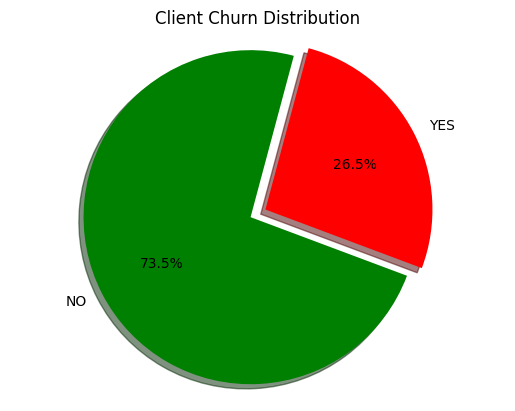

In [11]:
sizes = [5174, 1869]
labels = ['NO', 'YES']
explode = (0, 0.1)
colors = ['green', 'red']

fig1, ax1 = plt.subplots()

ax1.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct='%1.1f%%',
    shadow=True,
    startangle=75,
    colors=colors   # ← BURAYA ekliyoruz
)

ax1.axis('equal')
ax1.set_title("Client Churn Distribution")

plt.show()

In [12]:
df.groupby('gender').Churn.mean()

,Churn
gender,
0,0.269209
1,0.261603


<function matplotlib.pyplot.show(close=None, block=None)>

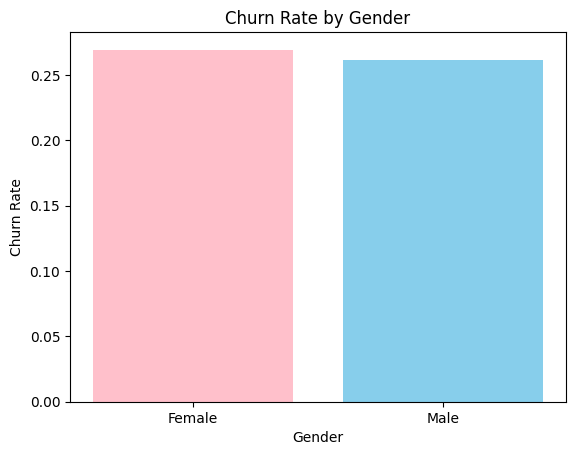

In [13]:
Churn_Mean = [0.269209, 0.261603]
Gender = ('Female','Male')
x_pos=np.arange(len(Churn_Mean))

plt.bar(x_pos, Churn_Mean, color=(['Pink','SkyBlue']))
plt.xticks(x_pos,Gender)
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Gender")
plt.show

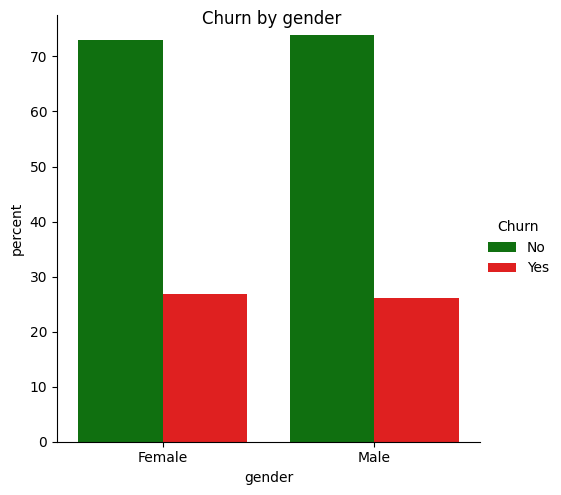

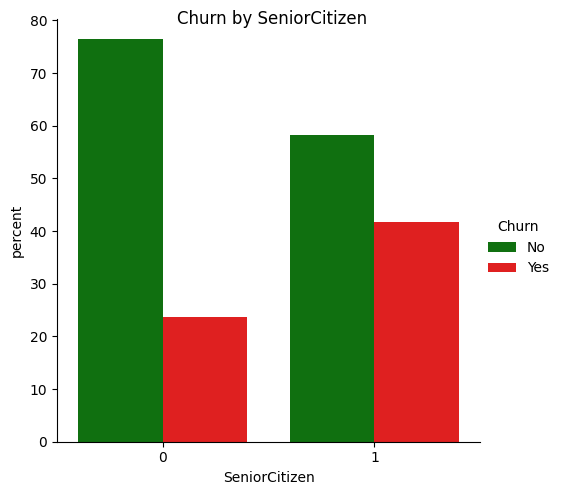

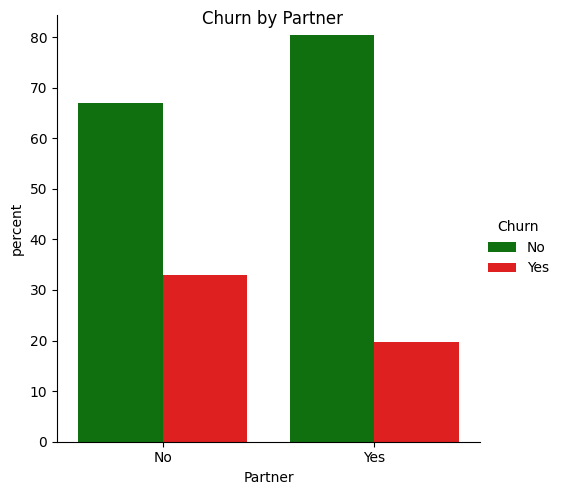

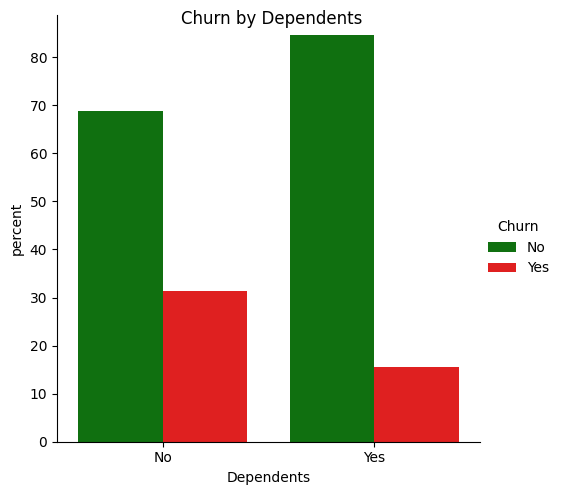

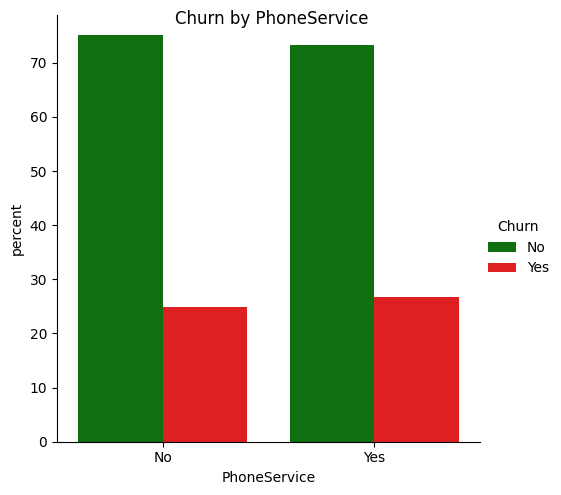

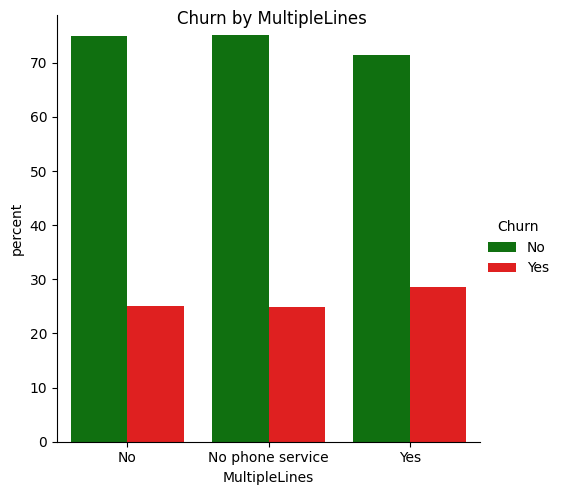

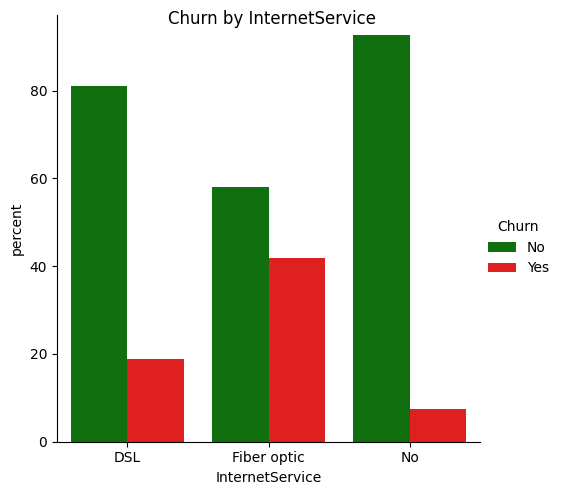

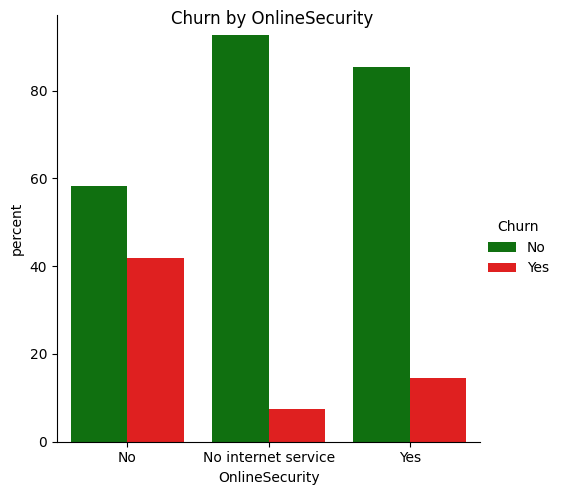

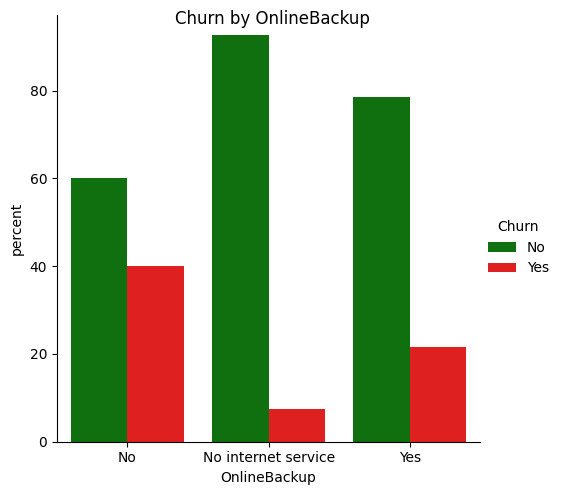

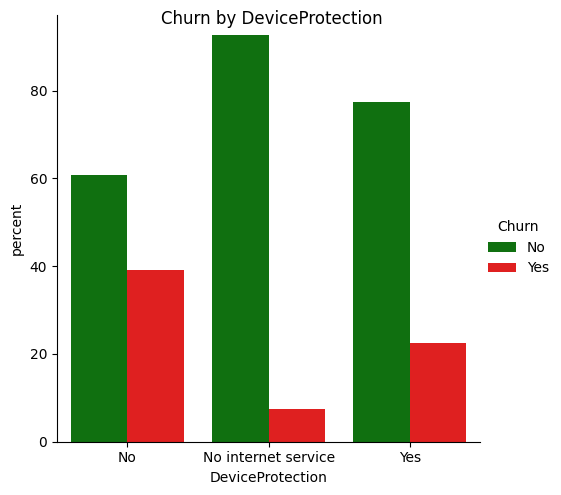

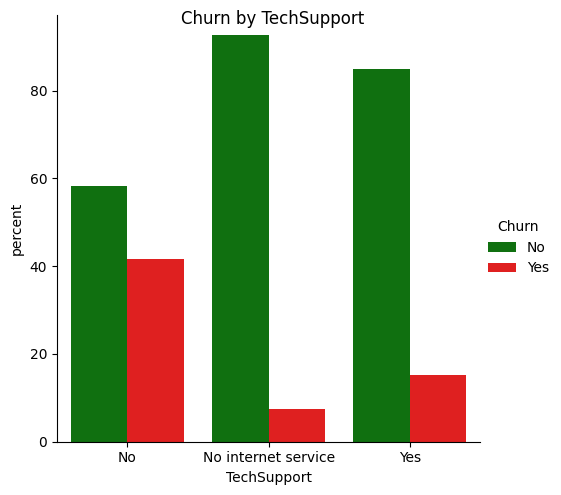

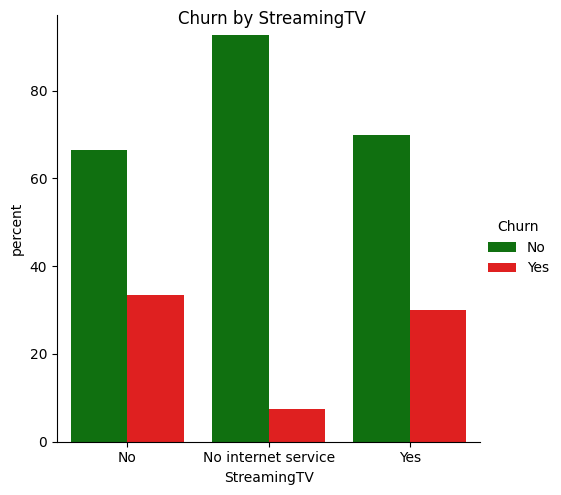

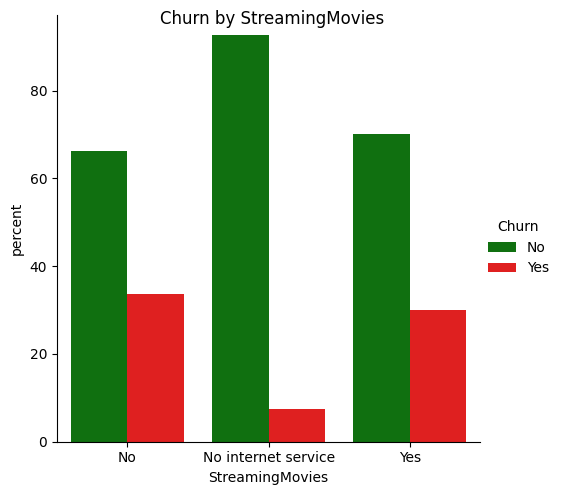

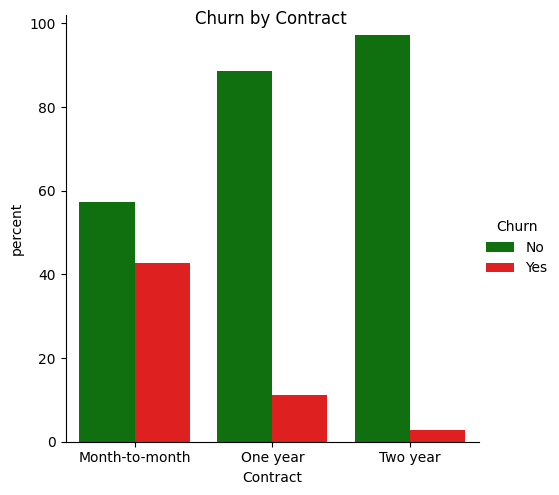

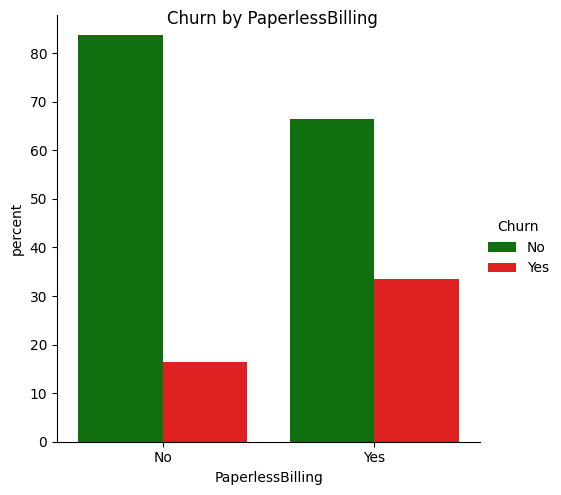

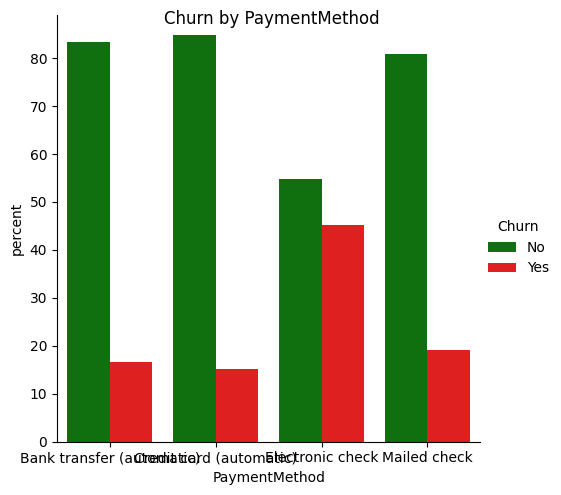

In [14]:
vars = df1.columns.tolist()
vars = [e for e in vars if e not in ('TotalCharges', 'MonthlyCharges','tenure', 'customerID', 'Churn')]

y = 'Churn'
for x in vars:
    plot = df1.groupby(x)[y]\
        .value_counts(normalize=True).mul(100)\
        .rename('percent').reset_index()\
        .pipe((sns.catplot,'data'), x=x, y='percent', hue=y, kind='bar',palette={'Yes': 'red', 'No': 'green'})
    plot.fig.suptitle("Churn by " + x)
    plot

/tmp/ipython-input-25357/116324556.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1.tenure)


<Axes: xlabel='tenure', ylabel='Density'>

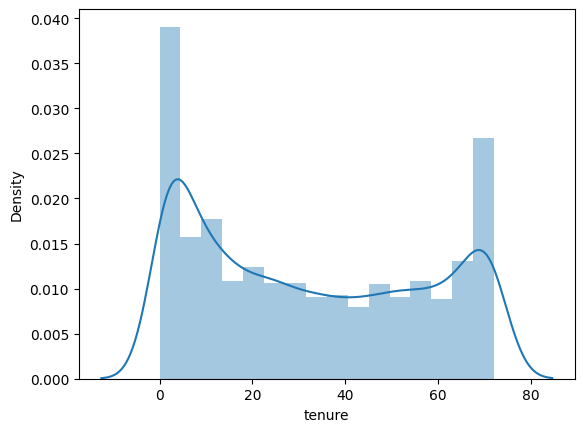

In [15]:
sns.distplot(df1.tenure)

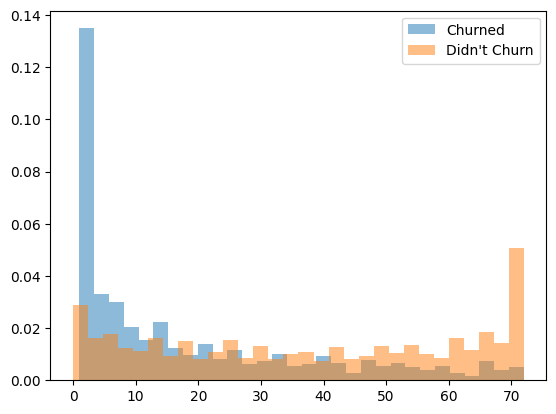

In [16]:
bins = 30
plt.hist(df1[df1.Churn == 'Yes'].tenure,
         bins, alpha=0.5, density=True, label='Churned')
plt.hist(df1[df1.Churn == 'No'].tenure,
         bins, alpha=0.5, density=True, label="Didn't Churn")
plt.legend(loc='upper right')
plt.show()

In [17]:
churners_number = len(df[df['Churn'] == 1])
print("Number of churners", churners_number)

churners = (df[df['Churn'] == 1])

non_churners = df[df['Churn'] == 0].sample(n=churners_number)
print("Number of non-churners", len(non_churners))
df3 = pd.concat([churners, non_churners], ignore_index=True)

Number of churners 1869
Number of non-churners 1869


In [18]:
def show_correlations(df, show_chart = True):
    fig = plt.figure(figsize = (20,10))
    corr = df.corr()
    if show_chart == True:
        sns.heatmap(corr,
                    xticklabels=corr.columns.values,
                    yticklabels=corr.columns.values,
                    annot=True)
    return corr

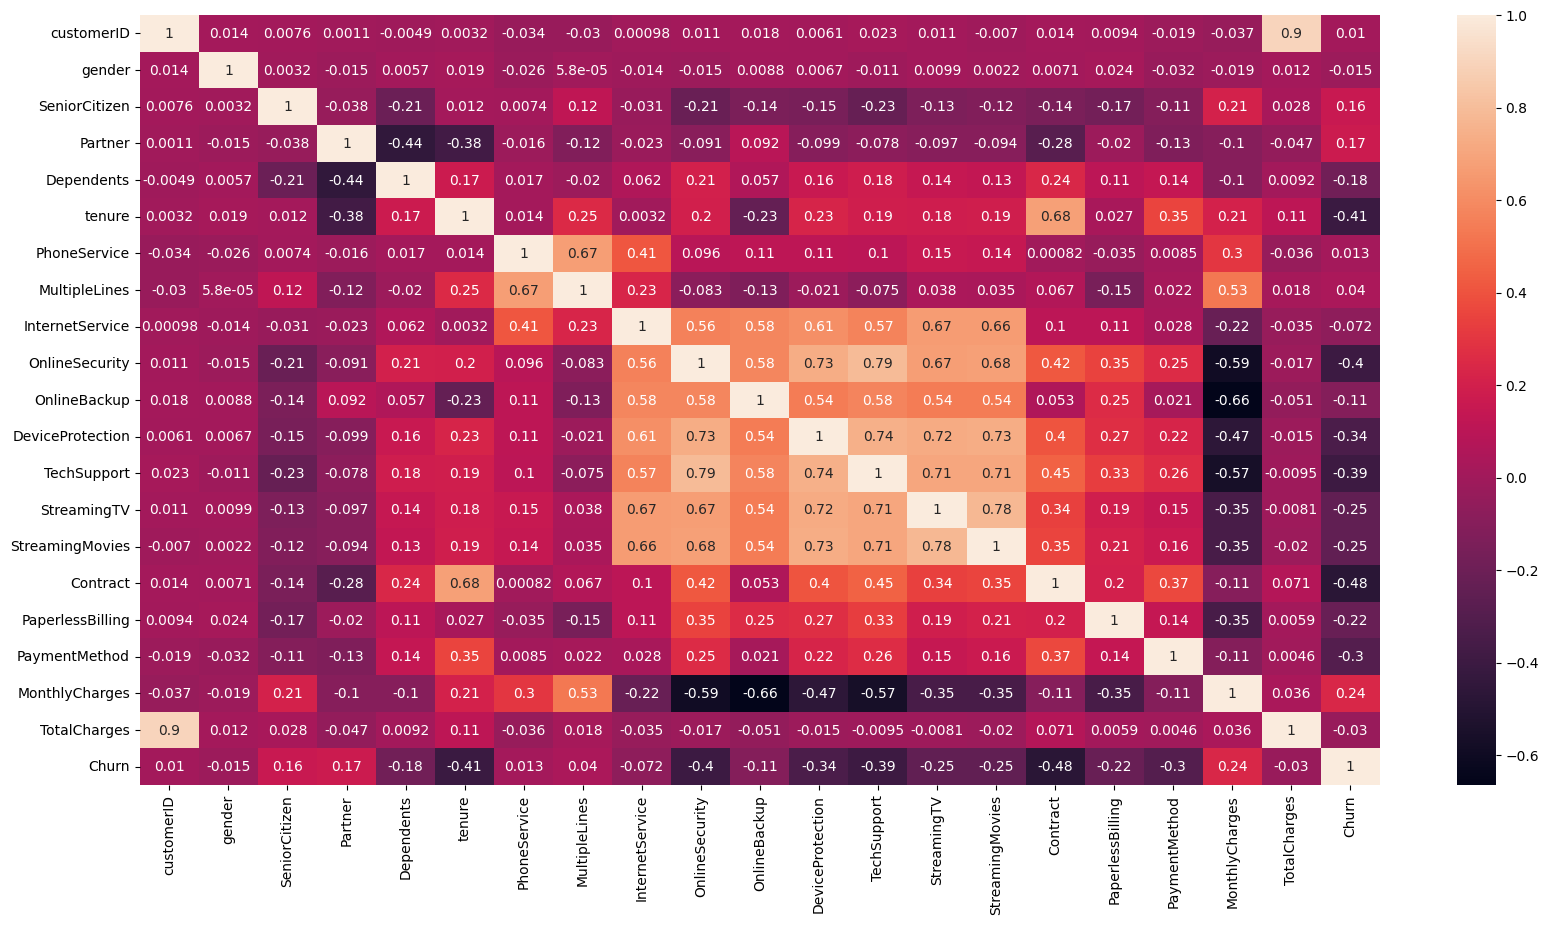

In [19]:
correlation_df = show_correlations(df3,show_chart=True)

In [20]:
y = df.Churn
df = df.drop(['Churn'], axis= 1)

In [21]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,29.85,0
1,1,1,0,1,0,34,1,1,0,1,1,1,0,0,0,1,1,1,56.95,1
2,2,1,0,1,0,2,1,1,0,1,0,0,0,0,0,0,0,1,53.85,2
3,3,1,0,1,0,45,0,0,0,1,1,1,1,0,0,1,1,2,42.30,3
4,4,0,0,1,0,2,1,1,1,0,1,0,0,0,0,0,0,0,70.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7038,1,0,0,1,24,1,2,0,1,1,1,1,1,1,1,0,1,84.80,6526
7039,7039,0,0,0,1,72,1,2,1,0,0,1,0,1,1,1,0,3,103.20,6527
7040,7040,0,0,0,1,11,0,0,0,1,1,0,0,0,0,0,0,0,29.60,6528
7041,7041,1,1,0,0,4,1,2,1,0,1,0,0,0,0,0,0,1,74.40,6529


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size = 0.20)

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
svclassifier = LinearSVC(max_iter=10000)
svclassifier.fit(X_train_scaled, y_train)
y_pred = svclassifier.predict(X_test_scaled)

In [32]:
y_pred = svclassifier.predict(X_test_scaled)
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[921 102]
 [175 211]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1023
           1       0.67      0.55      0.60       386

    accuracy                           0.80      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.79      0.80      0.80      1409

